Saving mldl 2.zip to mldl 2 (3).zip
===== Dataset Preview =====
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

===== Model Performance =====
                           MAE           MSE        R2        R2%
Linear Regression  4181.194474  3.359692e+07  0.783593  78.359298
Lasso (Base)       4181.510232  3.360115e+07  0.783566  78.356573
Ridge (Base)       4182.796597  3.360497e+07  0.783541  78.354107
Lasso (Tuned)      4210.603543  3.405660e+07  0.780632  78.063202
Ridge (Tuned)      4193.600652  3.366231e+07  0.783172  78.317176

Best Lasso Alpha: 100.0
Best Ridge Alpha: 7.543120063354623


<Figure size 1200x600 with 0 Axes>

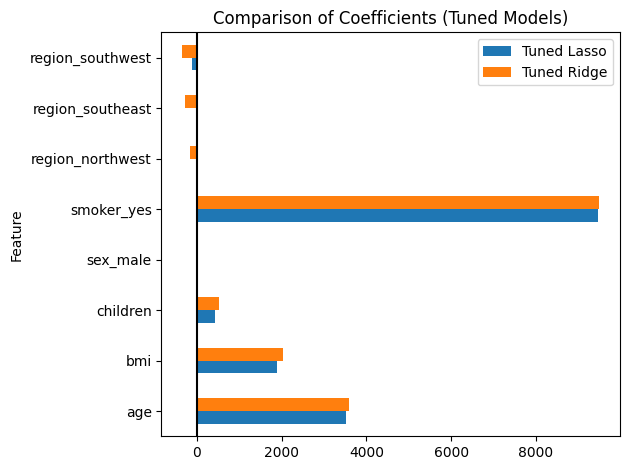

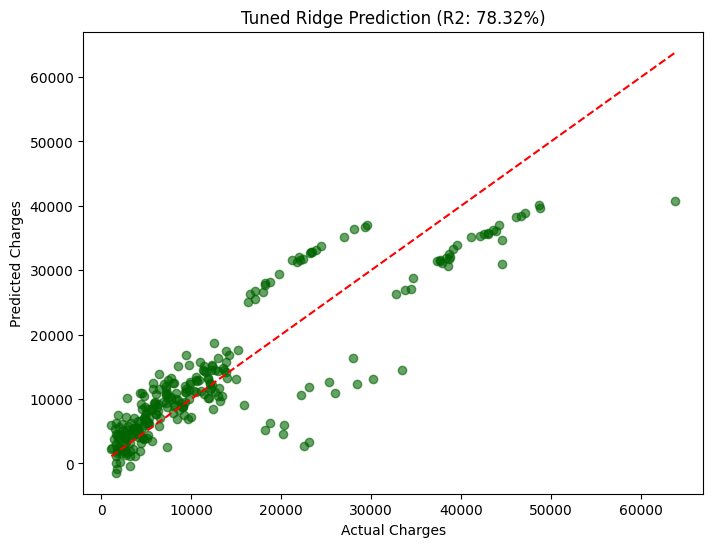


Optimal Lasso Alpha: 100.0
Optimal Ridge Alpha: 7.543120063354623


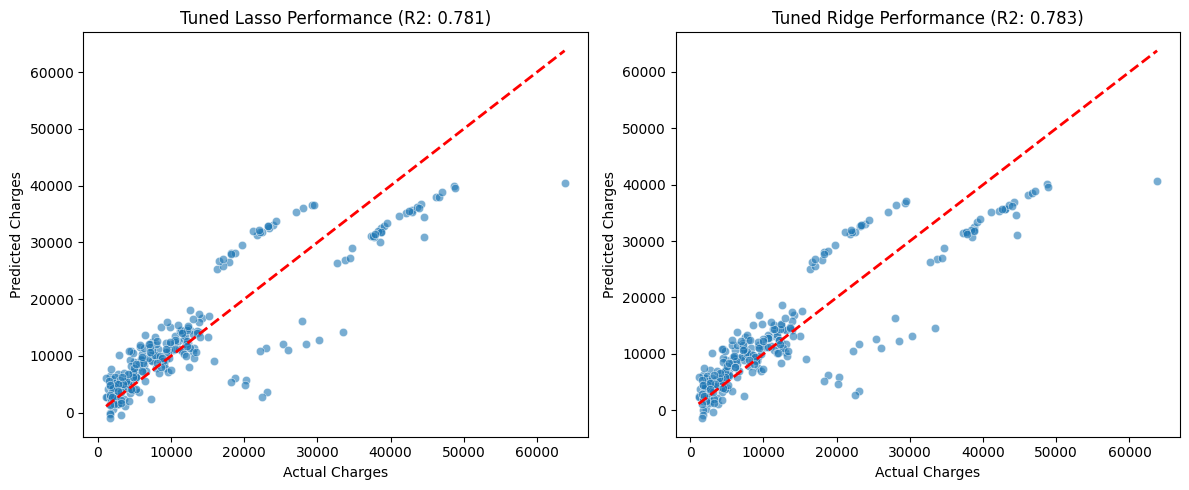

In [ ]:
# =====================================================
# Multi Linear, Lasso & Ridge Regression
# Dataset: Medical Insurance Cost Prediction
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# Upload Dataset (Colab Safe)
# ===============================

from google.colab import files
uploaded = files.upload()

# Automatically read uploaded file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("===== Dataset Preview =====")
print(df.head())

# ===============================
# Preprocessing
# ===============================

df = pd.get_dummies(df, drop_first=True)

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# Baseline Models
# ===============================

lr = LinearRegression().fit(X_train_scaled, y_train)
lasso_base = Lasso(alpha=1.0).fit(X_train_scaled, y_train)
ridge_base = Ridge(alpha=1.0).fit(X_train_scaled, y_train)

# ===============================
# Hyperparameter Tuning
# ===============================

alphas = np.logspace(-3, 2, 50)

grid_lasso = GridSearchCV(Lasso(), {'alpha': alphas},
                          cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)

grid_ridge = GridSearchCV(Ridge(), {'alpha': alphas},
                          cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

best_lasso = grid_lasso.best_estimator_
best_ridge = grid_ridge.best_estimator_

# ===============================
# Evaluation Function
# ===============================

def evaluate(model, X_t, y_t):
    preds = model.predict(X_t)
    r2 = r2_score(y_t, preds)
    return {
        'MAE': mean_absolute_error(y_t, preds),
        'MSE': mean_squared_error(y_t, preds),
        'R2': r2,
        'R2%': r2 * 100
    }

metrics = {
    'Linear Regression': evaluate(lr, X_test_scaled, y_test),
    'Lasso (Base)': evaluate(lasso_base, X_test_scaled, y_test),
    'Ridge (Base)': evaluate(ridge_base, X_test_scaled, y_test),
    'Lasso (Tuned)': evaluate(best_lasso, X_test_scaled, y_test),
    'Ridge (Tuned)': evaluate(best_ridge, X_test_scaled, y_test)
}

# ===============================
# Print Results
# ===============================

print("\n===== Model Performance =====")
print(pd.DataFrame(metrics).T)

print("\nBest Lasso Alpha:", grid_lasso.best_params_['alpha'])
print("Best Ridge Alpha:", grid_ridge.best_params_['alpha'])

# ===============================
# Visualization 1: Coefficient Comparison
# ===============================

plt.figure(figsize=(12,6))

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Tuned Lasso': best_lasso.coef_,
    'Tuned Ridge': best_ridge.coef_
}).set_index('Feature')

coef_df.plot(kind='barh')
plt.title("Comparison of Coefficients (Tuned Models)")
plt.axvline(0, color='black')
plt.tight_layout()
plt.show()

# ===============================
# Visualization 2: Predicted vs Actual (Tuned Ridge)
# ===============================

plt.figure(figsize=(8,6))
preds_ridge = best_ridge.predict(X_test_scaled)

plt.scatter(y_test, preds_ridge, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], '--r')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title(f"Tuned Ridge Prediction (R2: {metrics['Ridge (Tuned)']['R2%']:.2f}%)")
plt.show()
# ============================================
# Final Tuned Model Visualization (Like PDF)
# ============================================

print("\nOptimal Lasso Alpha:", grid_lasso.best_params_['alpha'])
print("Optimal Ridge Alpha:", grid_ridge.best_params_['alpha'])

# Predictions
pred_lasso = best_lasso.predict(X_test_scaled)
pred_ridge = best_ridge.predict(X_test_scaled)

plt.figure(figsize=(12,5))

# Lasso Plot
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r', lw=2)
plt.title(f"Tuned Lasso Performance (R2: {r2_score(y_test, pred_lasso):.3f})")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

# Ridge Plot
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=pred_ridge, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r', lw=2)
plt.title(f"Tuned Ridge Performance (R2: {r2_score(y_test, pred_ridge):.3f})")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.tight_layout()
plt.show()
